# MA0218 PTP Mini-Project 

This project notebook is done for a notebook of an average grade. A pair who writes a notebook of this level should expect a grade of B+ to A-

In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
return false; }

<IPython.core.display.Javascript object>

In [2]:
%%capture

!pip install -U imblearn
!pip install -U scikit-learn

# Primary libraries.
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
sb.set()                         

import re
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error

from imblearn.over_sampling import SMOTE 

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

In [3]:
train_labels_df = pd.read_csv('train_labels.csv') 
train_values_df = pd.read_csv('train_values.csv')  
test_values_df = pd.read_csv('test_values.csv')
train_dmg_df = train_values_df.merge(train_labels_df, how='inner', on='building_id')

In [4]:
train_labels_df = train_labels_df.sort_values(by=['building_id'])
train_values_df = train_values_df.sort_values(by=['building_id'])
test_values_df = test_values_df.sort_values(by=['building_id'])
train_dmg_df = train_dmg_df.sort_values(by=['building_id'])

In [5]:
train_labels_df.head()

,building_id,damage_grade
47748,4,2
212102,8,3
60133,12,3
34181,16,2
25045,17,2


In [6]:
train_dmg_df.head(20)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
47748,4,30,266,1224,1,25,5,2,t,r,...,0,0,0,0,0,0,0,0,0,2
212102,8,17,409,12182,2,0,13,7,t,r,...,0,0,0,0,0,0,0,0,0,3
60133,12,17,716,7056,2,5,12,6,o,r,...,0,0,0,0,0,0,0,0,0,3
34181,16,4,651,105,2,80,5,4,n,r,...,0,0,0,0,0,0,0,0,0,2
25045,17,3,1387,3909,5,40,5,10,t,r,...,0,0,0,0,0,0,0,0,0,2
234432,25,26,1132,6645,2,0,6,6,t,w,...,0,0,0,0,0,0,0,0,0,1
228351,28,8,1297,9721,2,0,2,6,t,r,...,0,0,0,0,0,0,0,0,0,3
33426,31,6,398,4512,2,30,10,5,t,r,...,0,0,0,0,0,0,0,0,0,3
144856,34,7,555,2763,3,40,5,6,t,r,...,0,0,0,0,0,0,0,0,0,2
246970,36,20,508,10459,2,5,7,6,t,w,...,0,0,0,0,0,0,0,0,0,1


In [7]:
test_values_df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
70763,7,10,151,708,2,25,8,6,t,r,...,0,0,0,0,0,0,0,0,0,0
10154,13,9,445,203,1,20,3,3,t,r,...,0,0,0,0,0,0,0,0,0,0
29324,49,10,760,4087,2,25,2,2,n,r,...,0,0,0,0,0,0,0,0,0,0
13082,92,26,1023,11319,2,20,5,4,t,r,...,0,0,0,0,0,0,0,0,0,0
66917,100,4,1202,5735,1,5,2,3,t,u,...,0,0,0,0,0,0,0,0,0,0


Does the damage vary based on region? Can we predict the general area `geo_level_1_id`? Can we predict the specific area? Can we fix class imbalance for different areas? These integers are categories?

Does the damage depend on the age of the building?

How does area and height percentage affect the building?

Can we use the binary variables to predict the damage?

<AxesSubplot:xlabel='age', ylabel='count'>

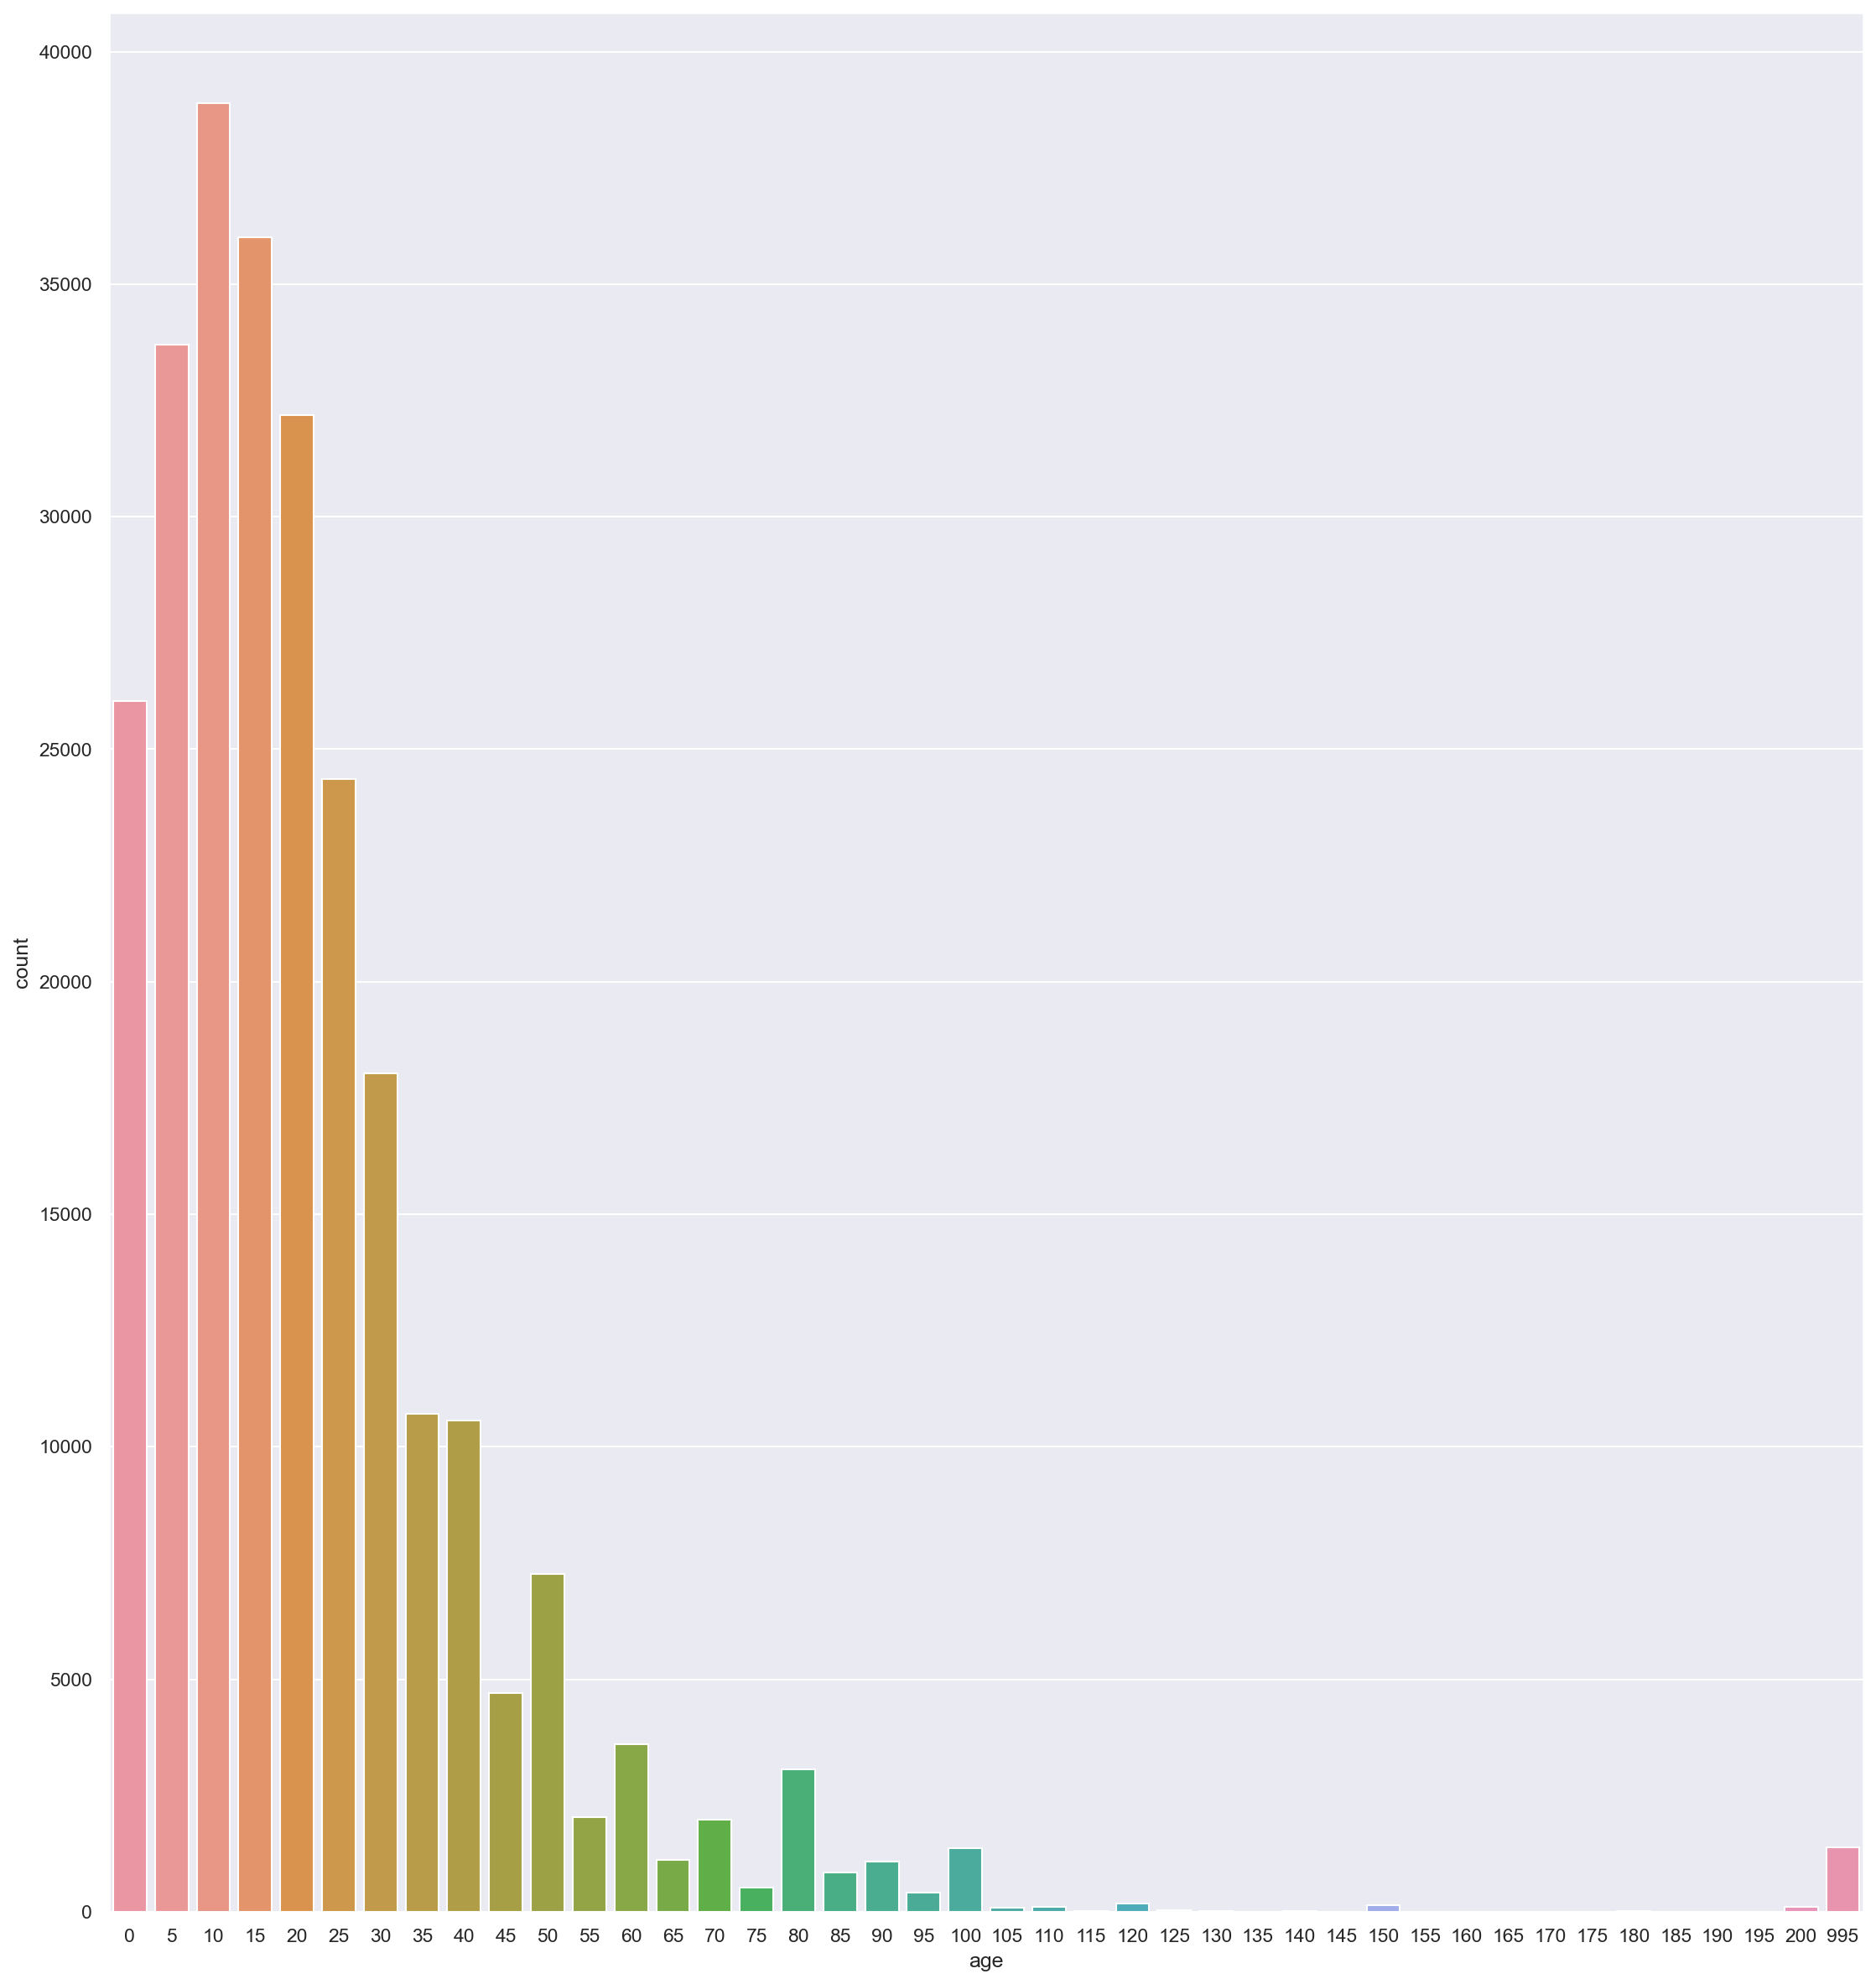

In [8]:
f, axes = plt.subplots(1, 1, figsize=(18, 20))
sb.countplot(x = train_values_df['age'])

10.0
30.0


<AxesSubplot:xlabel='age', ylabel='count'>

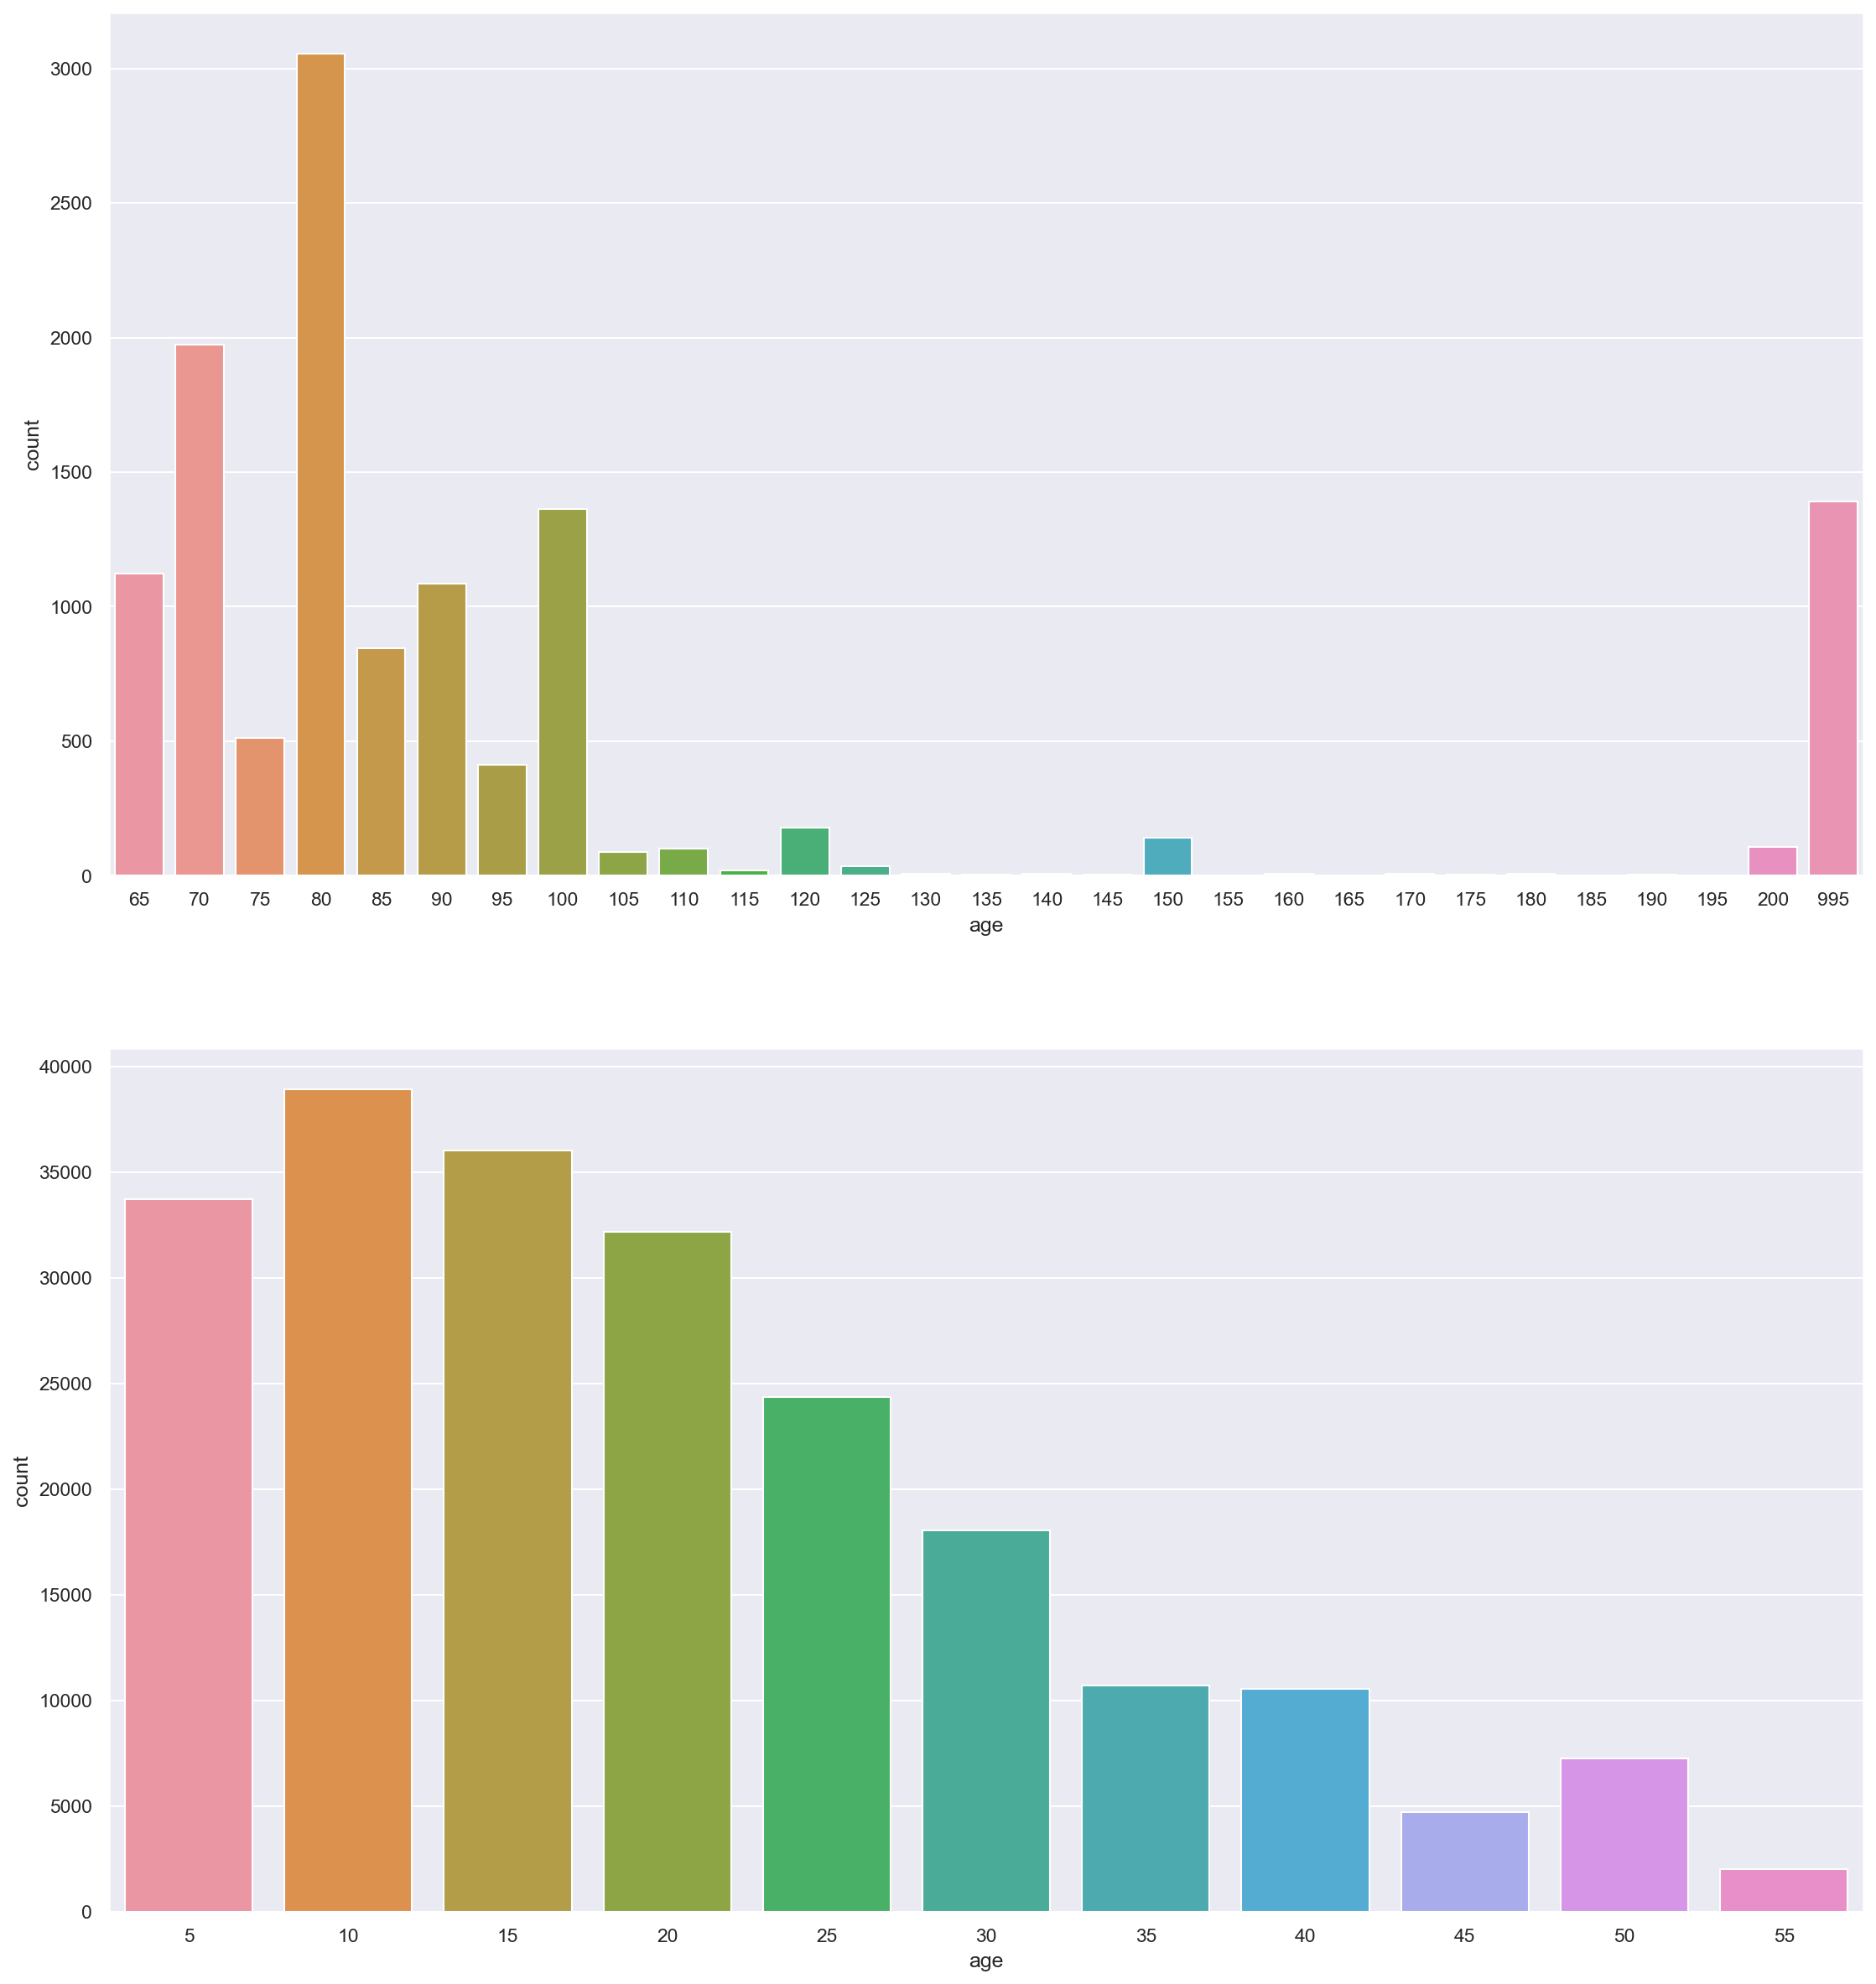

In [9]:
Q1 = train_dmg_df['age'].quantile(q = 0.25)
Q3 = train_dmg_df['age'].quantile(q = 0.75)
print(Q1)
print(Q3)
IQR = Q3 - Q1

train_age_values_df = train_dmg_df.loc[(train_dmg_df['age'] > (Q1 - 0.5 * IQR))]
train_old_values_df = train_age_values_df.loc[(train_dmg_df['age'] > (Q3 + 1.5 * IQR))]
train_new_values_df = train_age_values_df.loc[(train_dmg_df['age'] < (Q3 + 1.5 * IQR))]

f, axes = plt.subplots(2, 1, figsize=(18, 20))
sb.countplot(x = train_old_values_df['age'], ax = axes[0])
sb.countplot(x = train_new_values_df['age'], ax = axes[1])

In [10]:
train_old_values_df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
34181,16,4,651,105,2,80,5,4,n,r,...,0,0,0,0,0,0,0,0,0,2
128277,170,4,484,11114,2,70,5,5,n,r,...,0,0,0,0,0,0,0,0,0,2
248471,389,3,1387,2791,4,100,3,8,t,r,...,0,0,0,0,0,0,0,0,0,3
209273,474,17,21,6605,2,80,6,4,t,u,...,0,0,0,0,0,0,0,0,0,3
41958,599,17,566,7559,3,80,7,7,n,r,...,0,0,0,0,0,0,0,0,0,3


<AxesSubplot:xlabel='damage_grade', ylabel='age'>

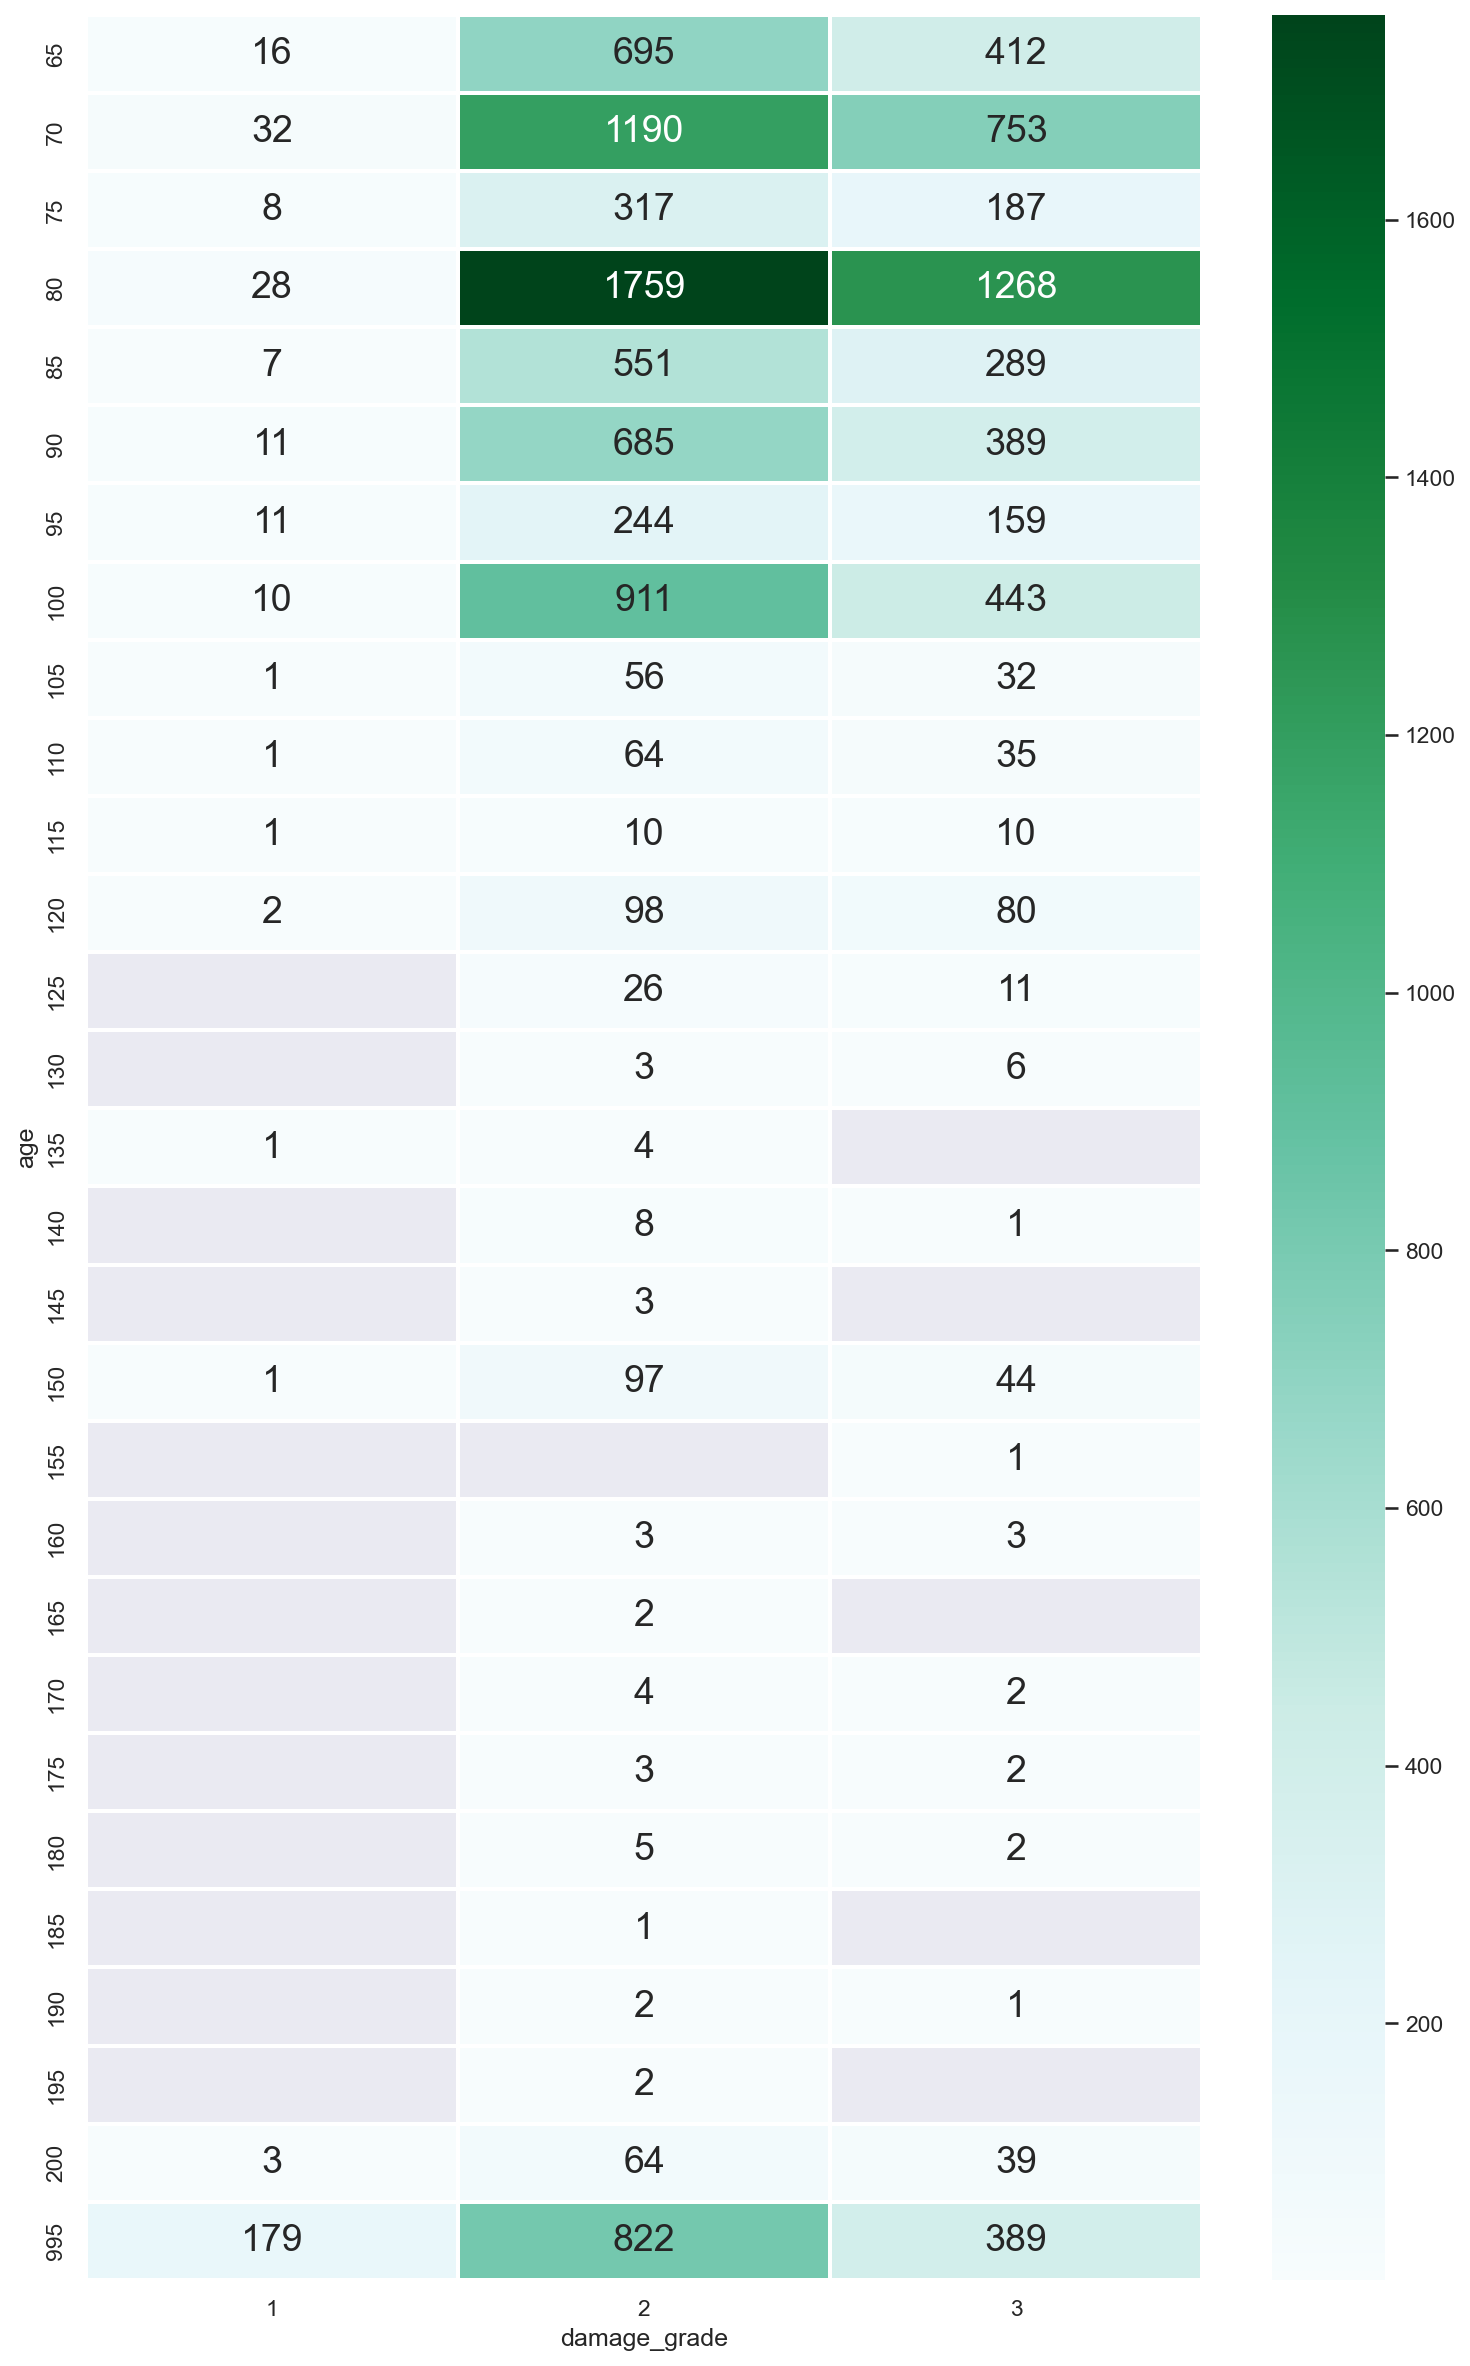

In [11]:
f, axes = plt.subplots(1, 1, figsize=(12, 20))
sb.heatmap(train_old_values_df.groupby(['age',
                                 'damage_grade']).size().unstack(),
                                  linewidths = 1,
                                  annot = True,
                                  fmt = 'g',
                                  annot_kws = {"size": 18},
                                  cmap = "BuGn")

<AxesSubplot:xlabel='damage_grade', ylabel='age'>

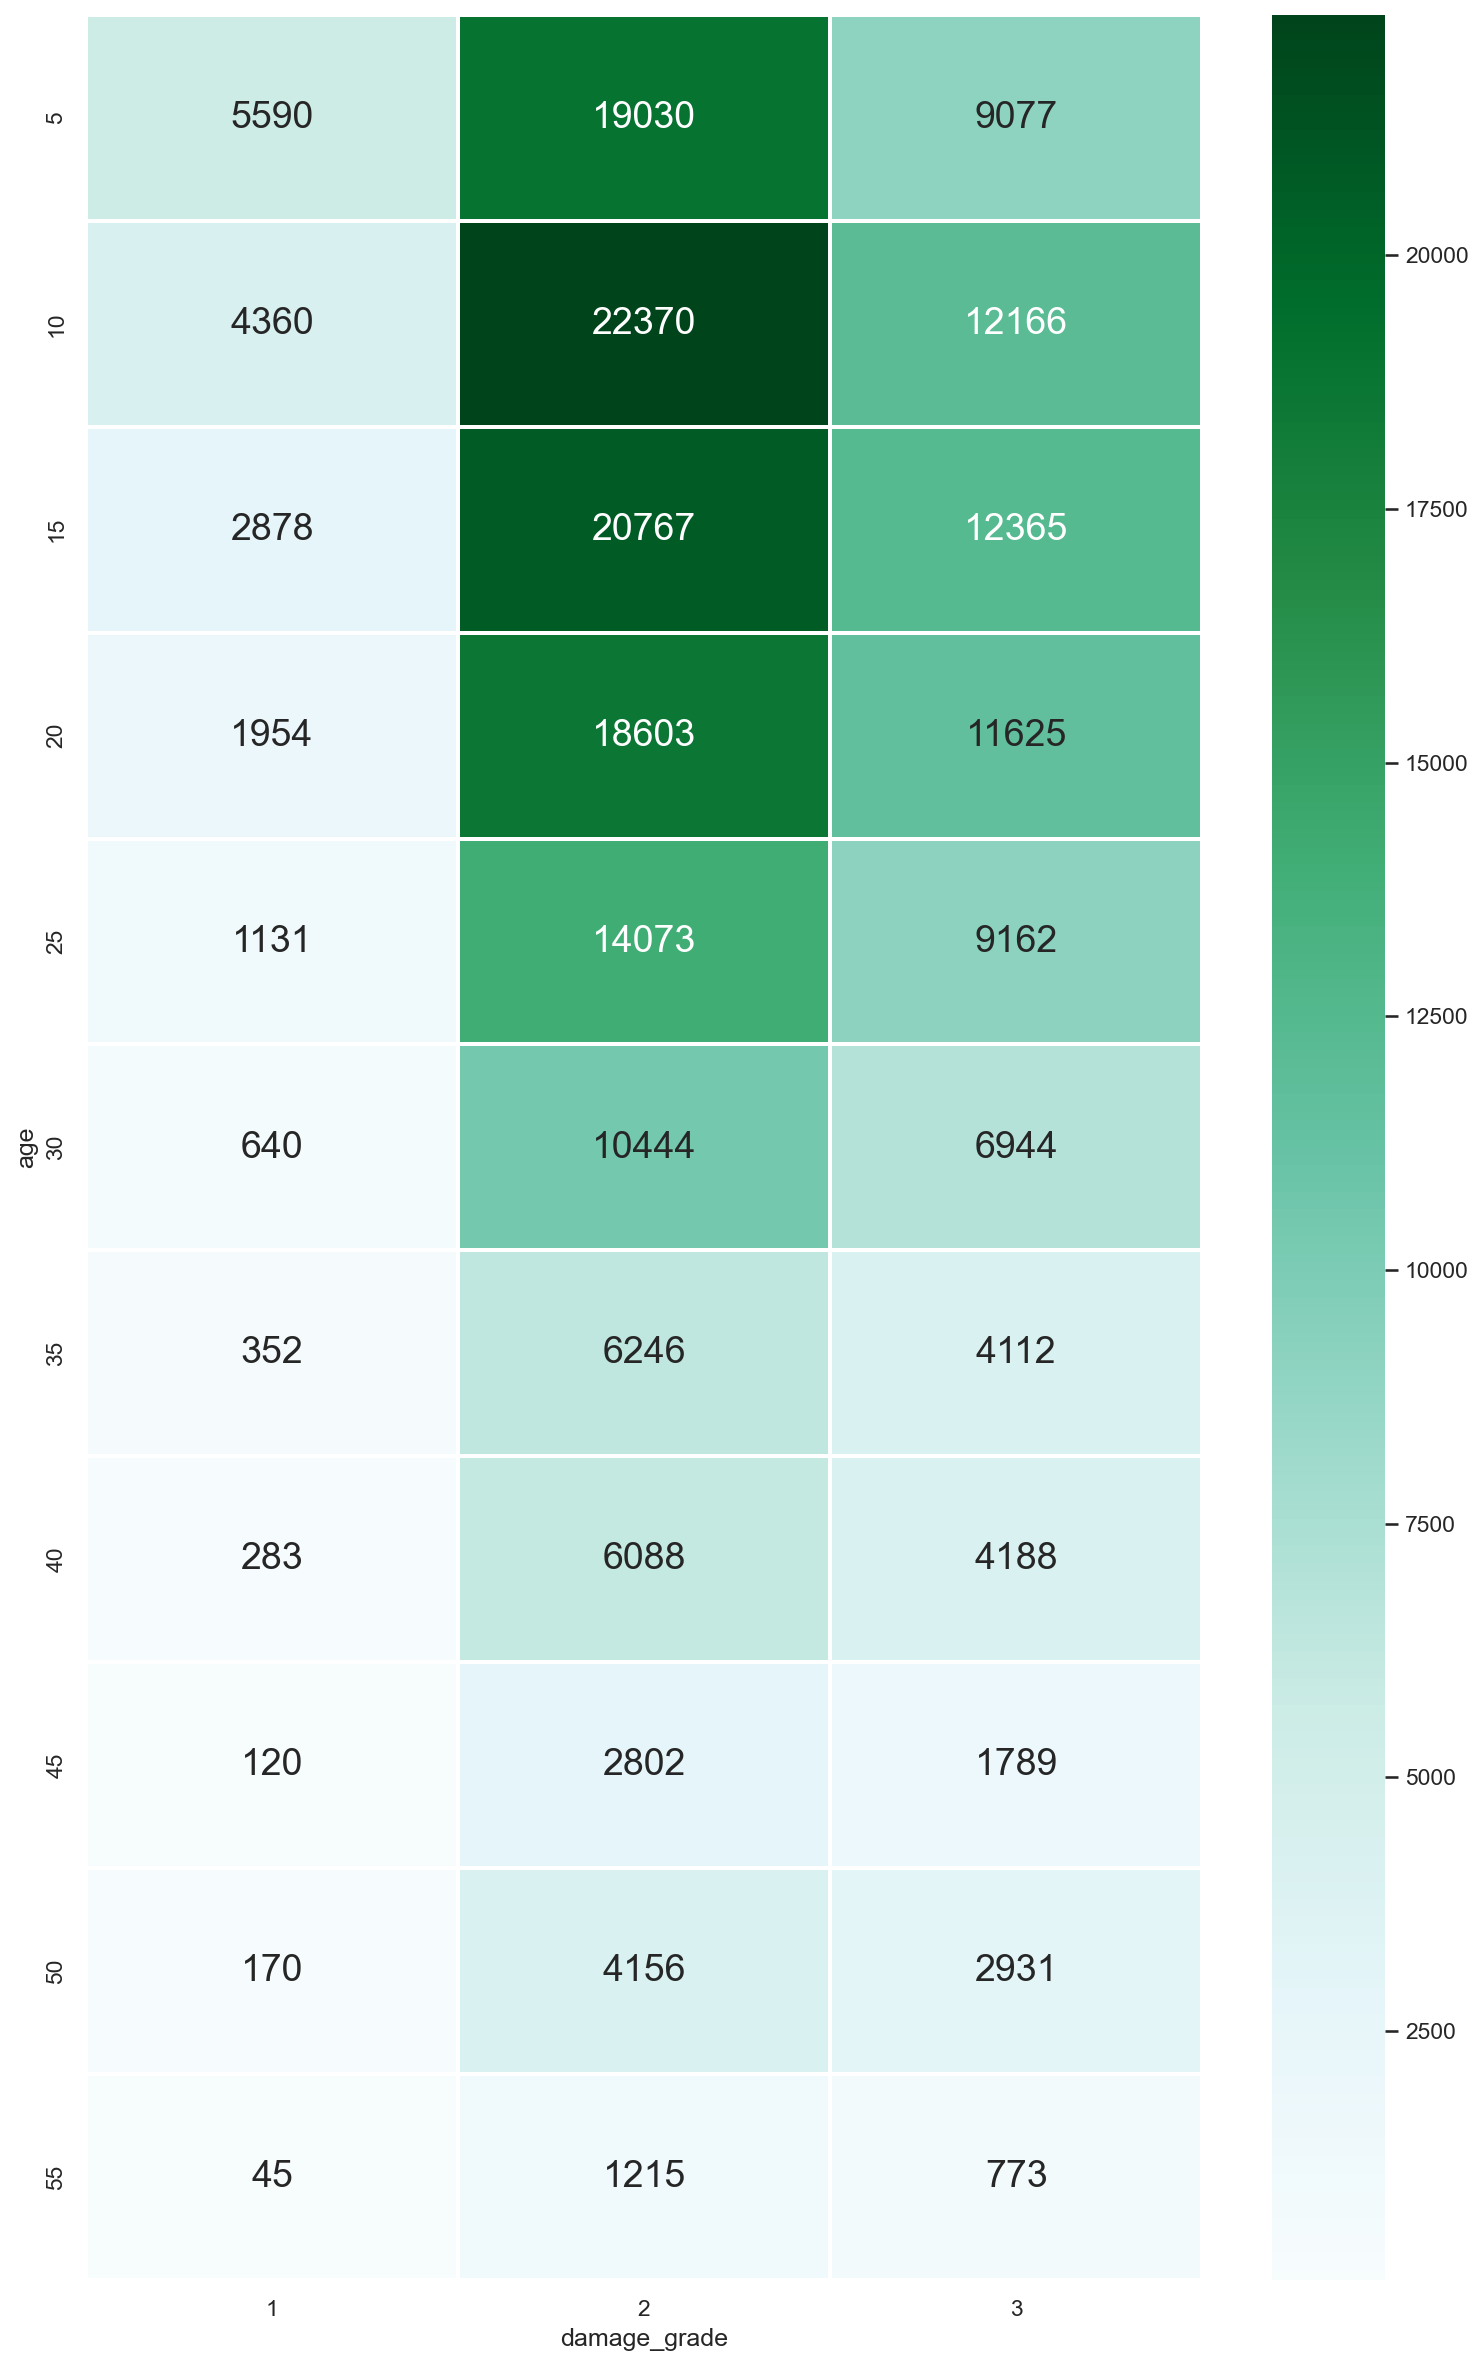

In [12]:
f, axes = plt.subplots(1, 1, figsize=(12, 20))
sb.heatmap(train_new_values_df.groupby(['age',
                                 'damage_grade']).size().unstack(),
                                  linewidths = 1,
                                  annot = True,
                                  fmt = 'g',
                                  annot_kws = {"size": 18},
                                  cmap = "BuGn")

Gaussian Naive Bayes
Accuracy: 0.445
Confusion Matrix:  
 [[42485 19198 15036]
 [16664 18133 15989]
 [28839 50657 56963]]
                    Classification Report 
               precision    recall  f1-score   support

           1       0.48      0.55      0.52     76719
           2       0.21      0.36      0.26     50786
           3       0.65      0.42      0.51    136459

    accuracy                           0.45    263964
   macro avg       0.45      0.44      0.43    263964
weighted avg       0.51      0.45      0.46    263964

Random Forest Classifier
Accuracy: 0.472
Confusion Matrix:  
 [[54020 25801 21055]
 [15044 25750 22133]
 [18924 36437 44800]]
                    Classification Report 
               precision    recall  f1-score   support

           1       0.61      0.54      0.57    100876
           2       0.29      0.41      0.34     62927
           3       0.51      0.45      0.48    100161

    accuracy                           0.47    263964
   macro av

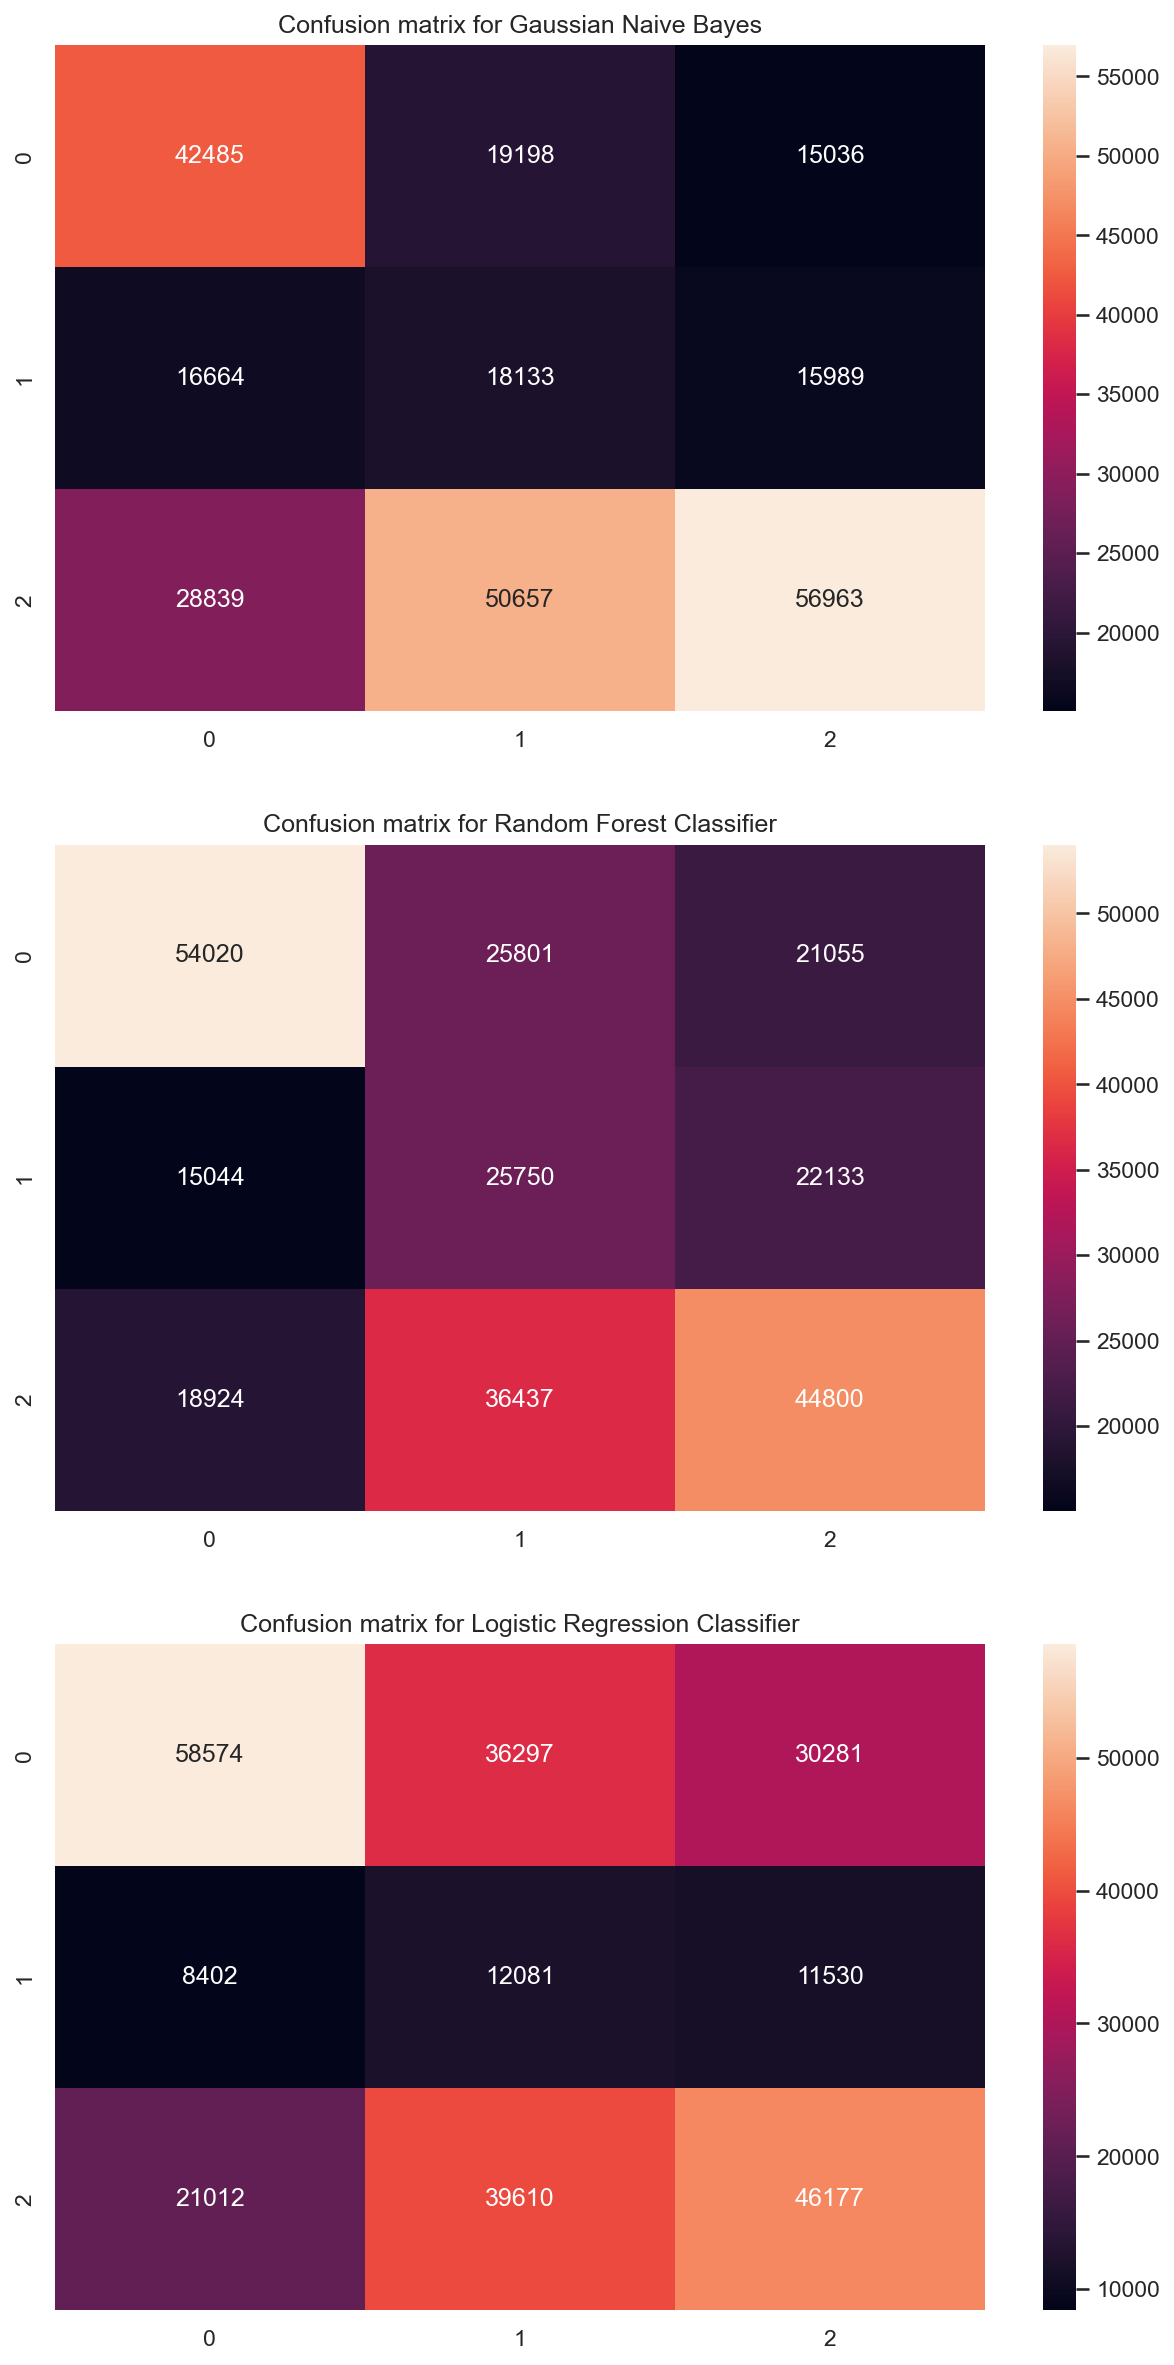

In [13]:
def MP_split(dataframe, X_str, y_str):
    X_df = pd.DataFrame(dataframe[X_str])
    y_df = pd.DataFrame(dataframe[y_str])
    X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.3)
    smote = SMOTE()
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    X_test_sm, y_test_sm = smote.fit_resample(X_test, y_test)
    return X_train_sm, X_test_sm, y_train_sm, y_test_sm

def MP_model(mod, model_name, x_train, x_test, y_train, y_test):
    """Given a SMOTE train-test split, apply the ML algorithm. Then, check classification accuracy."""
    mod.fit(x_train, y_train.values.ravel())
    print(model_name)
    accuracy_float = cross_val_score(mod, x_train, y_train.values.ravel(), scoring = "accuracy", cv = 5)
    predictions_TFR = cross_val_predict(mod, x_train, y_train.values.ravel(), cv = 5)
    print("Accuracy:", round(accuracy_float.mean(),3))
    confusionmatrix = confusion_matrix(predictions_TFR, y_train.values.ravel())
    print("Confusion Matrix:  \n", confusionmatrix)
    print("                    Classification Report \n",classification_report(predictions_TFR, y_train.values.ravel()))
    return mod, confusionmatrix

def MP_classifiers(X_train, X_test, y_train, y_test):
    """Procedure. Runs 3 different classifiers on the data-set."""
    f, axes = plt.subplots(3, 1, figsize=(10,20))

    gnb_model = GaussianNB() # Gaussian Naive Bayes
    gnb_model, confusionmatrix = MP_model(gnb_model, "Gaussian Naive Bayes", X_train, X_test, y_train, y_test)
    sb.heatmap(confusionmatrix, annot = True, fmt=".0f", ax=axes[0])
    axes[0].set_title('Confusion matrix for Gaussian Naive Bayes')

    ran_model = RandomForestClassifier(n_estimators=50) # Random Forest Classifier
    ran_model, confusionmatrix = MP_model(ran_model, "Random Forest Classifier", X_train, X_test, y_train, y_test)
    sb.heatmap(confusionmatrix, annot = True, fmt=".0f", ax=axes[1])
    axes[1].set_title('Confusion matrix for Random Forest Classifier')

    log_model = LogisticRegression(max_iter = 1000) # Logistic Regression
    log_model, confusionmatrix = MP_model(log_model, "Logistic Regression", X_train, X_test, y_train, y_test)
    sb.heatmap(confusionmatrix, annot = True, fmt=".0f", ax=axes[2])
    axes[2].set_title('Confusion matrix for Logistic Regression Classifier')


X_train, X_test, y_train, y_test = MP_split(train_new_values_df, ['age', 'area_percentage', 'height_percentage'], 'damage_grade')
MP_classifiers(X_train, X_test, y_train, y_test)

Gaussian Naive Bayes
Accuracy: 0.51
Confusion Matrix:  
 [[3199  577  492]
 [  95  946  822]
 [2046 3817 4026]]
                    Classification Report 
               precision    recall  f1-score   support

           1       0.60      0.75      0.67      4268
           2       0.18      0.51      0.26      1863
           3       0.75      0.41      0.53      9889

    accuracy                           0.51     16020
   macro avg       0.51      0.55      0.49     16020
weighted avg       0.65      0.51      0.53     16020

Random Forest Classifier
Accuracy: 0.628
Confusion Matrix:  
 [[4738  757  581]
 [ 282 2301 1715]
 [ 320 2282 3044]]
                    Classification Report 
               precision    recall  f1-score   support

           1       0.89      0.78      0.83      6076
           2       0.43      0.54      0.48      4298
           3       0.57      0.54      0.55      5646

    accuracy                           0.63     16020
   macro avg       0.63      0

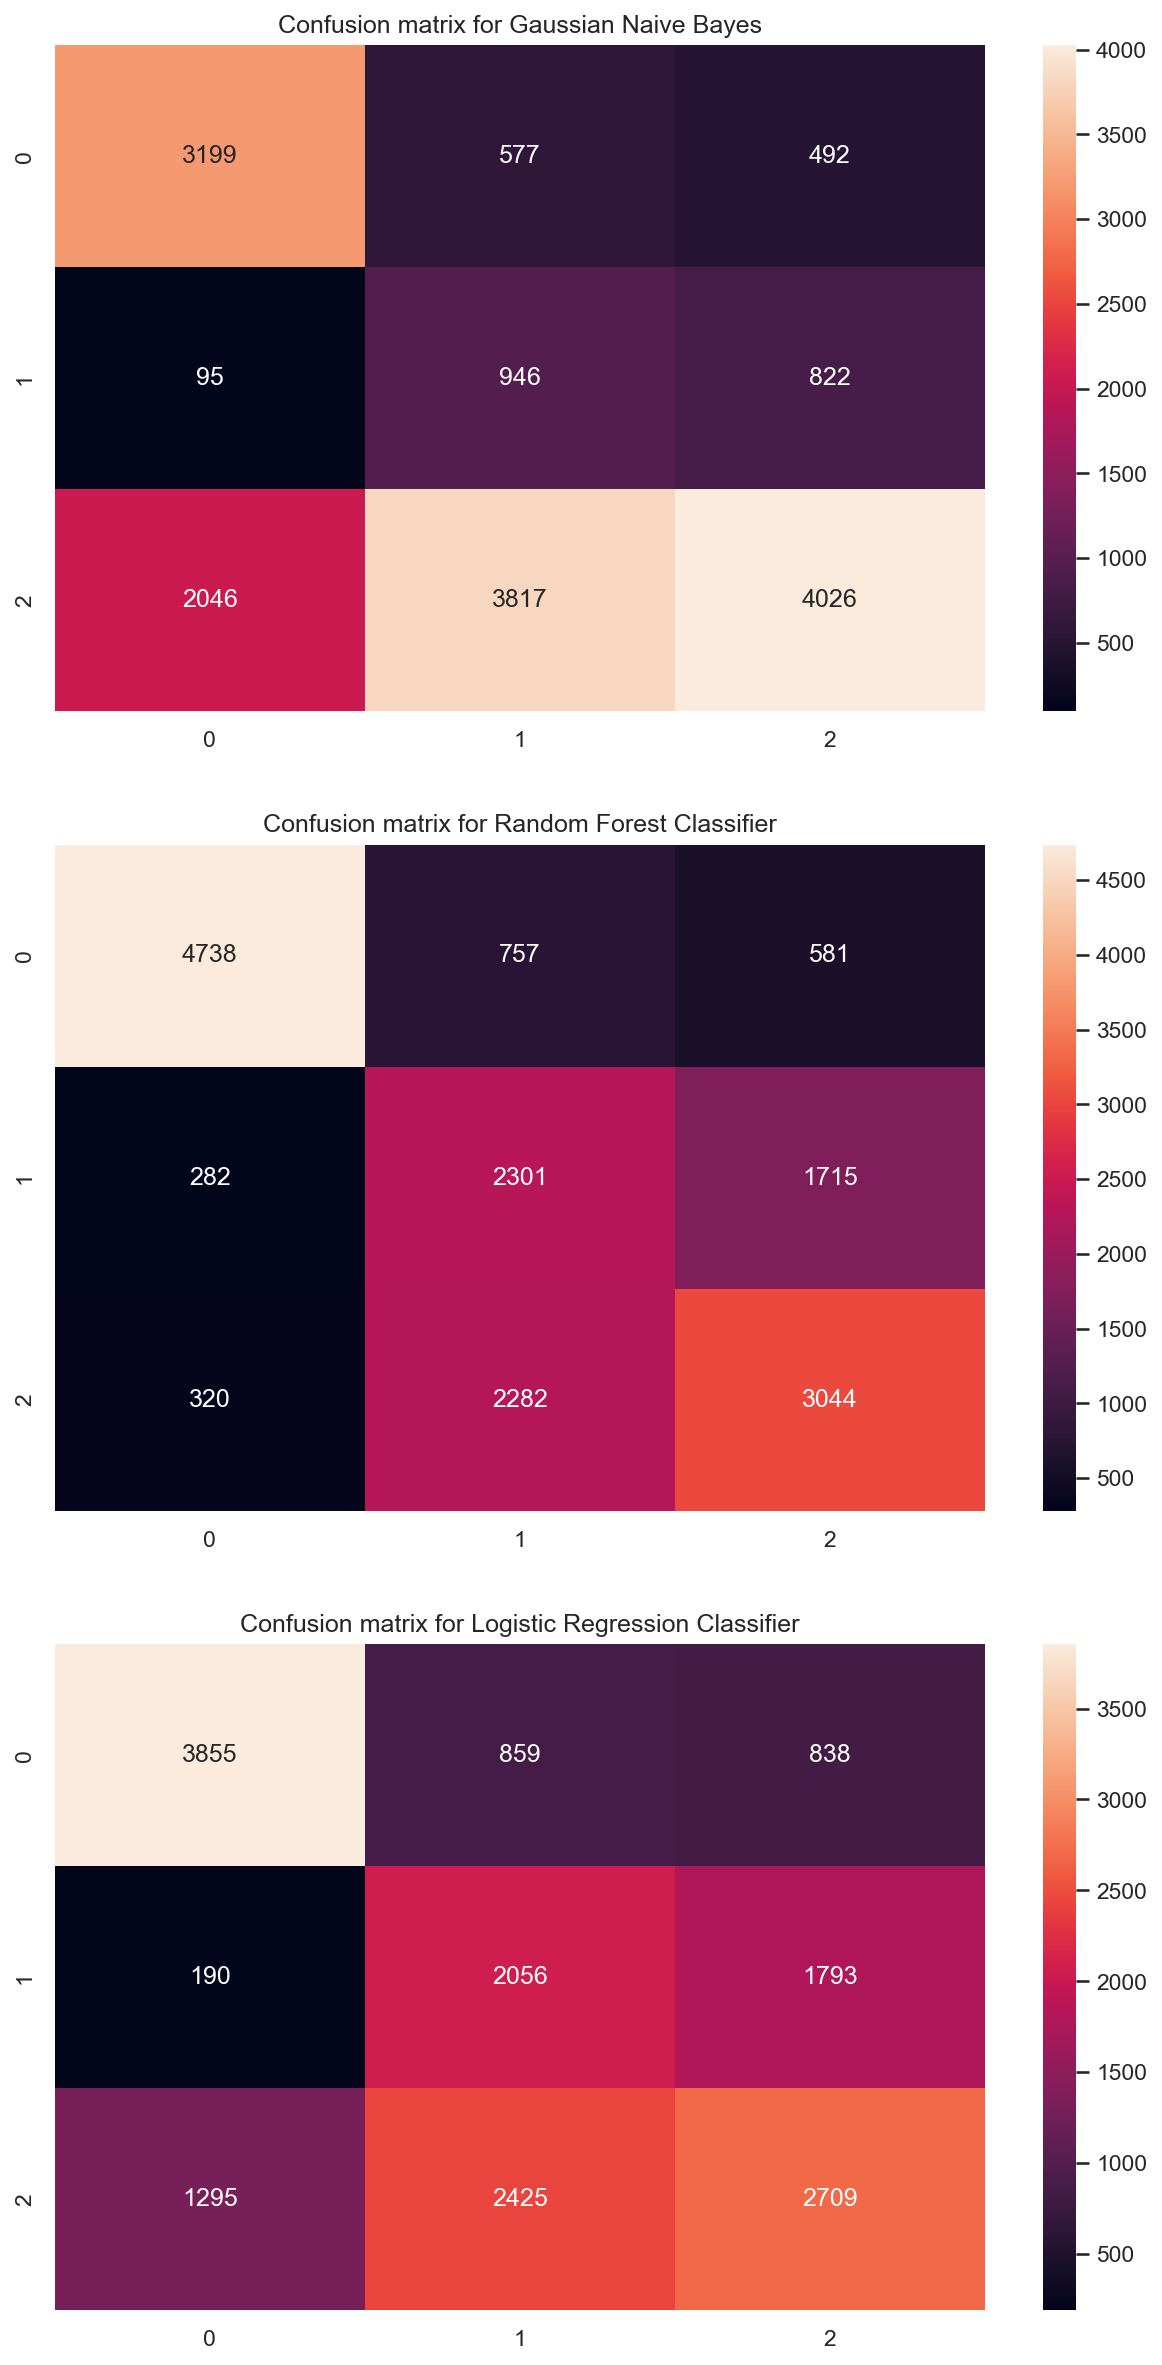

In [14]:
X_train, X_test, y_train, y_test = MP_split(train_old_values_df, ['age', 'area_percentage', 'height_percentage'], 'damage_grade')
MP_classifiers(X_train, X_test, y_train, y_test)